In [39]:
from pathlib import Path
import pandas as pd
import numpy as np

In [40]:
data_path_hsa = '../../../../data/raw/HSA'  # specify your path here
folder = Path(data_path_hsa)  # change to your folder path
print(f'Reading CSV files from {folder}')
csv_files = sorted(folder.glob('*.csv'))

if not csv_files:
    print(f'No CSV files found in {folder}')
else:
    # read each CSV into a dict of DataFrames keyed by filename (without suffix)
    dfs = {p.stem: pd.read_csv(p) for p in csv_files}

    # optional: concatenate all into a single DataFrame
    combined = pd.concat(dfs.values(), ignore_index=True)

    print(f'Read {len(dfs)} files. Combined shape: {combined.shape}')

Reading CSV files from ..\..\..\..\data\raw\HSA
Read 57 files. Combined shape: (251892, 5)


In [41]:
def make_continuous(x, threshold=None):
    """
    Unwraps a resetting position signal.
    x: array-like
    threshold: negative jump threshold (auto if None)
    """
    x = np.array(x)
    dx = np.diff(x)

    # Auto threshold: any large negative jump
    if threshold is None:
        threshold = -0.5 * np.max(x)  

    offset = 0
    x_cont = np.zeros_like(x)

    for i in range(len(x)):
        if i > 0 and dx[i-1] < threshold:
            # Counter reset detected
            offset += x[i-1]
        x_cont[i] = x[i] + offset

    return x_cont


In [52]:
import sys
sys.path.append("../../py")   # or an absolute path

from machine_tool_parser import MachineToolParser

In [53]:
MDACHSFile = '../../../../data/cnc_config_data/MDACHSX4.TEA'
MDANTRXFile ='../../../../data/cnc_config_data/MDANTRX4.TEA'
parser = MachineToolParser(
    MDACHSFile,
    MDANTRXFile,
    drive="DR4"
)


In [54]:
# rename columns in all loaded DataFrames and save renamed CSVs to a new folder
prepro_path = '../../../../data/preprocessed/HSA' 
#prepro_path.mkdir(parents=True, exist_ok=True)

# rename columns for clarity
col_map = {
    '+/Nck/!SD/nckServoDataActCurr32 [u1; 4]': 'iqAx4',
    '+/Channel/!RP/rpa [u1; 11]': 'rpa',
    '+/Nck/!SD/nckServoDataActPower32 [u1; 4]': 'powerAx4',
    '+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]': 'velAx4'
}


for stem, df in list(dfs.items()):
    # apply the column mapping (rename ignores keys not present)
    df_renamed = df.rename(columns=col_map)
    # update the in-memory dict to hold renamed DataFrame
    dfs[stem] = df_renamed
    # save with the same filename (stem) into the new folder
    df_renamed = df_renamed.drop(columns="rpa")
    ##
    df_renamed = parser.convert_signals(df_renamed)

    out_file = f'{prepro_path}/{stem}.csv'
    print(f'Saving renamed DataFrame to {out_file}')
    df_renamed.to_csv(out_file, index=False)
    print(f"Saved: {out_file}")

c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1028_161651.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1028_161651.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1028_162435.csv


c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


Saved: ../../../../data/preprocessed/HSA/Trace_1028_162435.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_110641.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_110641.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_122711.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_122711.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_123420.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_123420.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_123530.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_123530.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_123701.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_123701.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_123727.csv


c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\fu

...

Saved: ../../../../data/preprocessed/HSA/Trace_1030_125208.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125233.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125233.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125327.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125327.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125353.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125353.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125418.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125418.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125443.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125443.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125508.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125508.csv
Saving renamed DataFrame to ../../../../data/preprocess

c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\fu

Saved: ../../../../data/preprocessed/HSA/Trace_1030_125558.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125623.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125623.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125649.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125649.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125734.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125734.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125800.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125800.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125825.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125825.csv
Saving renamed DataFrame to ../../../../data/preprocessed/HSA/Trace_1030_125850.csv
Saved: ../../../../data/preprocessed/HSA/Trace_1030_125850.csv
Saving renamed DataFrame to ../../../../data/preprocess

c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\fu

Saved: ../../../../data/preprocessed/HSA/Trace_1030_130055.csv


In [55]:
df_renamed.isnull().sum()

time                     0
iqAx4                    0
powerAx4                 0
velAx4                   0
rpm                      0
omega_rad_s              0
I_pct                    0
I_A                      0
P_pct                    0
P_kW                     0
P_W                      0
T_Nm                     0
domega_rad_s2          210
domega_rad_s2_clean      0
dtype: int64

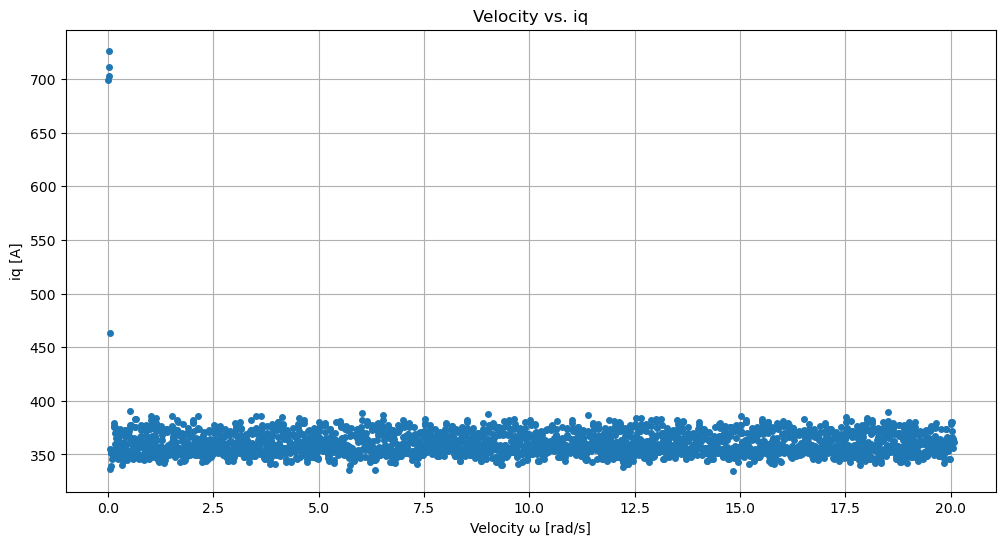

171

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_renamed["time"], df_renamed["velAx4"], linewidth=1, marker='o', markersize=4, linestyle='None')
plt.xlabel("Velocity ω [rad/s]")
plt.ylabel("iq [A]")
plt.title("Velocity vs. iq")
plt.grid(True)
plt.show()
results_df.size